In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
plt.rcParams.update({
    'figure.figsize'   : (14, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
sns.set_palette("muted")

print("Libraries loaded")

Libraries loaded


In [5]:
df = pd.read_csv('../Data/Cleaned/mta_ridership_cleaned.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

In [6]:
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().strftime('%d %b %Y')} -> {df['date'].max().strftime('%d %b %Y')}")
print(f"Nulls: {df.isnull().sum().sum()}")

Loaded: 1,776 rows x 21 columns
Date range: 01 Mar 2020 -> 09 Jan 2025
Nulls: 0


In [7]:
TARGET = 'subway_ridership'

RIDERSHIP_COLS = [
    'subway_ridership', 'bus_ridership', 'lirr_ridership',
    'metro_north_ridership', 'access_ride_trips',
    'bridges_tunnels_traffic', 'staten_island_ridership'
]

BASELINE_COLS = [
    'subway_pct_baseline', 'bus_pct_baseline', 'lirr_pct_baseline',
    'metro_north_pct_baseline', 'access_ride_pct_baseline',
    'bridges_tunnels_pct_baseline', 'staten_island_pct_baseline'
]

FLAG_COLS = ['is_covid', 'is_weekend', 'is_holiday', 'is_outlier']

print(f"Variables defined")
print(f"TARGET        : {TARGET}")
print(f"Ridership cols: {len(RIDERSHIP_COLS)}")
print(f"Baseline cols : {len(BASELINE_COLS)}")
print(f"Flag cols     : {len(FLAG_COLS)}")

Variables defined
TARGET        : subway_ridership
Ridership cols: 7
Baseline cols : 7
Flag cols     : 4


In [9]:
print ('Univariate Analysis')
print (f'Column: {TARGET}')
print (f'Count: {df[TARGET].count():>12,}')
print (f'Mean : {df[TARGET].mean():>12,.0f}')
print (f'Median: {df[TARGET].median():>12,.0f}')
print(f"Std Dev: {df[TARGET].std():>12,.0f}")
print(f"Min    : {df[TARGET].min():>12,.0f}")
print(f"Max    : {df[TARGET].max():>12,.0f}")
print(f"Skew   : {df[TARGET].skew():>12.4f}")
print(f"Kurt   : {df[TARGET].kurtosis():>12.4f}")
print(f"CV     : {df[TARGET].std()/df[TARGET].mean()*100:>11.2f}%") 

Univariate Analysis
Column: subway_ridership
Count:        1,776
Mean :    2,541,830
Median:    2,505,354
Std Dev:    1,067,641
Min    :      198,399
Max    :    5,498,809
Skew   :      -0.1656
Kurt   :      -0.9273
CV     :       42.00%


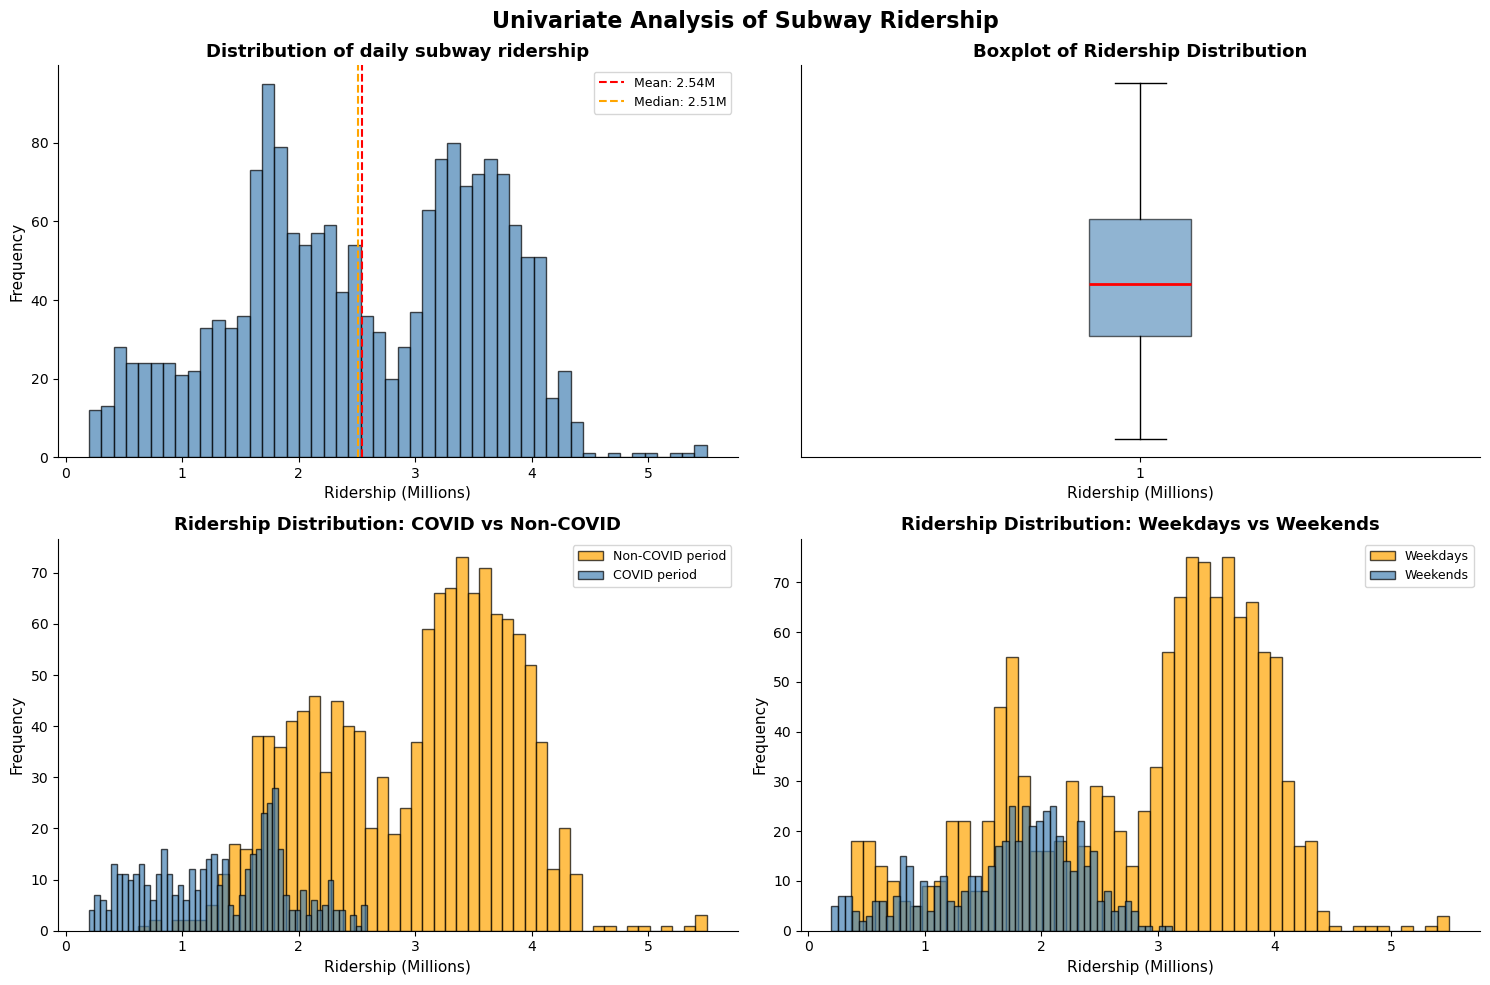

Saved to Reports


<Figure size 1400x500 with 0 Axes>

In [17]:
fig,axes = plt.subplots(2, 2, figsize=(15, 10))

#histogram for daily subway ridership
axes [0,0].hist(df[TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', alpha = 0.7)
axes[0,0].axvline(df[TARGET].mean()/1e6, color='red',
                  linestyle='--', linewidth=1.5,
                  label=f"Mean: {df[TARGET].mean()/1e6:.2f}M")
axes[0,0].axvline(df[TARGET].median()/1e6, color='orange',
                  linestyle='--', linewidth=1.5,
                  label=f"Median: {df[TARGET].median()/1e6:.2f}M")
axes[0,0].set_title(f"Distribution of daily subway ridership", fontweight='bold') 
axes[0,0].set_xlabel("Ridership (Millions)")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend(fontsize=9)

#boxplot for ridership distribution
axes[0,1].boxplot(df[TARGET]/1e6, vert=True, patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.6),
                  medianprops=dict(color='red', linewidth=2),
                  flierprops=dict(marker='o', markerfacecolor='red',
                                  markersize=4, alpha=0.5))
axes[0,1].set_title(f"Boxplot of Ridership Distribution", fontweight='bold')
axes[0,1].set_xlabel("Ridership (Millions)")
axes[0,1].set_yticks([])

#ridership distribution: COVID vs Non-COVID
axes[1,0].hist(df[df['is_covid']==0][TARGET]/1e6, bins=50, color='orange', edgecolor='black', label = 'Non-COVID period', alpha = 0.7)
axes[1,0].hist(df[df['is_covid']==1][TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', label = 'COVID period', alpha = 0.7)
axes[1,0].set_title(f"Ridership Distribution: COVID vs Non-COVID", fontweight='bold')
axes[1,0].set_xlabel("Ridership (Millions)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend(fontsize=9)

axes[1,1].hist(df[df['is_weekend']==0][TARGET]/1e6, bins=50, color='orange', edgecolor='black', label = 'Weekdays', alpha = 0.7)
axes[1,1].hist(df[df['is_weekend']==1][TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', label = 'Weekends', alpha = 0.7)
axes[1,1].set_title(f"Ridership Distribution: Weekdays vs Weekends", fontweight='bold')
axes[1,1].set_xlabel("Ridership (Millions)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend(fontsize=9)

plt.suptitle ('Univariate Analysis of Subway Ridership', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('../Reports/03_univariate_analysis.png', dpi=150, bbox_inches='tight')
print("Saved to Reports")